In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import pickle
from matplotlib import pyplot as plt
import os
import arviz as az
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict
import numpy as np
import scipy.stats as stats



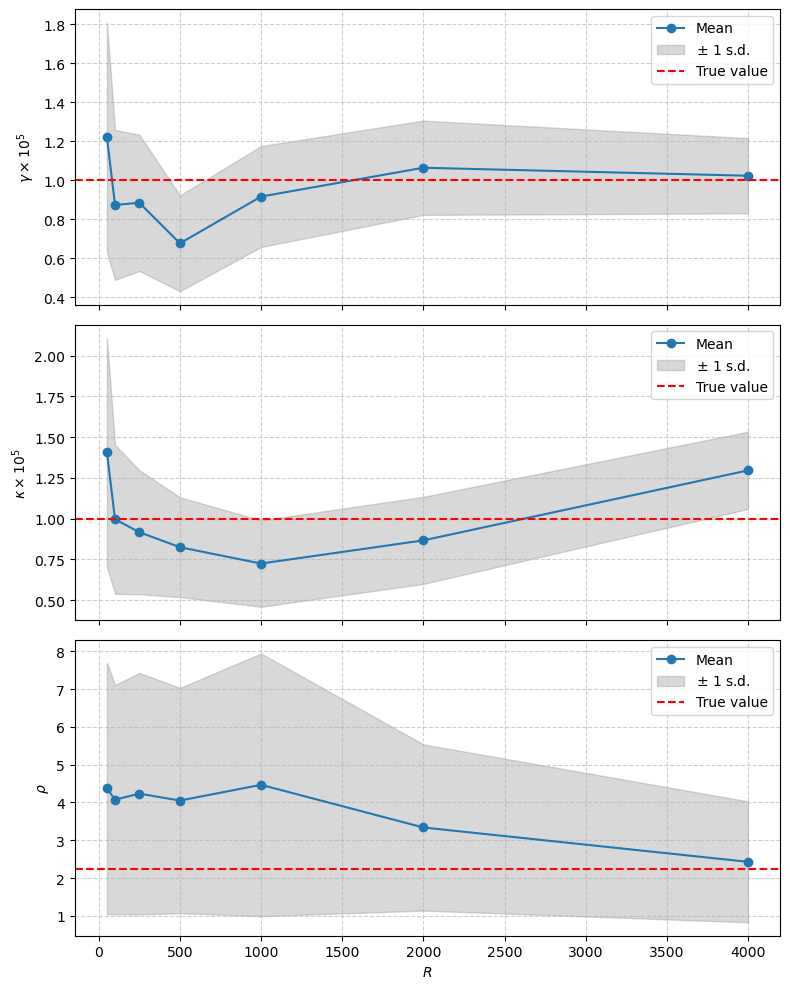

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Data from the table
R = np.array([50, 100, 250, 500, 1000, 2000, 4000])

gamma_mean = np.array([1.220, 0.873, 0.884, 0.676, 0.916, 1.064, 1.023])
gamma_sd   = np.array([0.590, 0.385, 0.350, 0.246, 0.259, 0.242, 0.193])

kappa_mean = np.array([1.406, 0.996, 0.917, 0.825, 0.725, 0.867, 1.296])
kappa_sd   = np.array([0.702, 0.457, 0.380, 0.306, 0.265, 0.267, 0.237])

rho_mean   = np.array([4.373, 4.073, 4.233, 4.050, 4.466, 3.338, 2.430])
rho_sd     = np.array([3.327, 3.031, 3.195, 2.979, 3.473, 2.198, 1.599])

# True values
gamma_true = 1.000
kappa_true = 1.000
rho_true   = 2.231

# Plot
fig, axs = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

params = [
    (gamma_mean, gamma_sd, gamma_true, r'$\gamma \times 10^5$'),
    (kappa_mean, kappa_sd, kappa_true, r'$\kappa \times 10^5$'),
    (rho_mean, rho_sd, rho_true, r'$\rho$')
]

for ax, (mean, sd, true_val, label) in zip(axs, params):
    ax.plot(R, mean, marker='o', label='Mean')
    ax.fill_between(R, mean - sd, mean + sd, color='gray', alpha=0.3, label=r'$\pm$ 1 s.d.')
    ax.axhline(true_val, color='red', linestyle='--', label='True value')
    ax.set_ylabel(label)
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.6)

axs[-1].set_xlabel(r'$R$')

plt.tight_layout()
plt.show()


In [54]:

from bayesian import simulate_data
params = {
        "kappa": 1e-4,   # transient impact scale
        "rho": 2.231,    # decay rate
        "gamma": 1e-4    # permanent impact scale
    }
sigma = 0.95   # volatility
tau = 0.01
min_gap = 100
seed = 100
n_trades = 5
data = simulate_data(params, sigma, tau, n_trades, min_gap, seed)


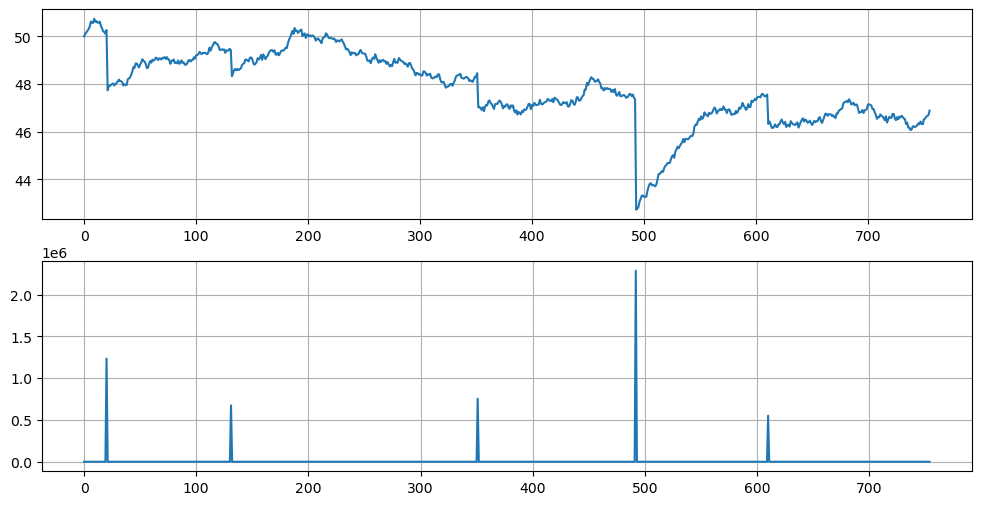

In [55]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6))
axes[0].plot(data[0], label='Price')
axes[1].plot(data[1], label='Volume')
axes[0].grid()
axes[1].grid()

302001


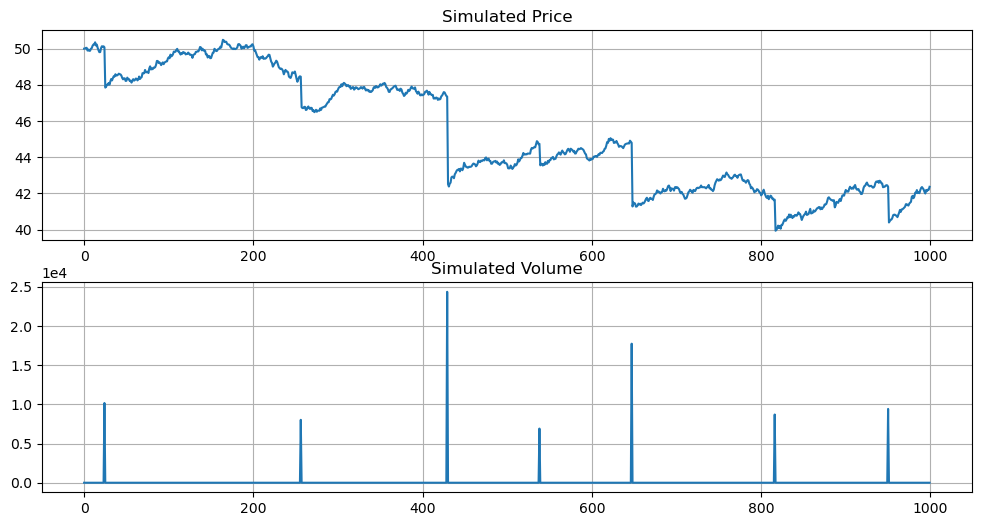

In [52]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6))
with open('/nfs/home/dannis/AC-model/TIM/TIM_simulated_data/20250826/sim_data_2000_gap_100_seed_109.pkl','rb') as f:
    data = pickle.load(f)
    print(len(data[0]))
axes[0].plot(data[0][:1000], label='Price')
axes[1].plot(data[1][:1000] * 0.01, label='Volume')
axes[0].set_title('Simulated Price')
axes[1].set_title('Simulated Volume')
axes[1].ticklabel_format(axis='y', style='sci', scilimits=(0,0))
axes[0].grid()
axes[1].grid()

plt.savefig('simulated_price_volume.png')
plt.show()

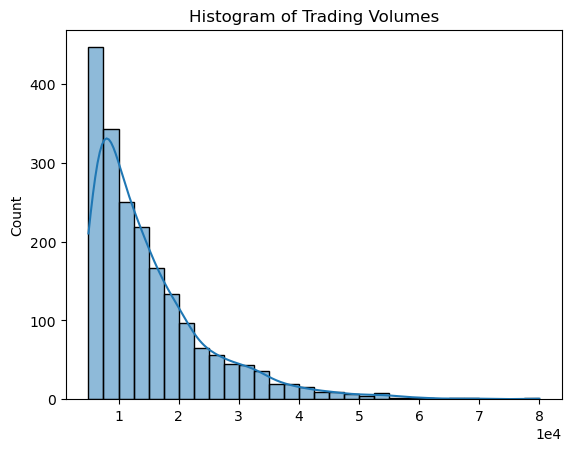

In [53]:
sns.histplot(data[1][data[1] != 0] * 0.01, bins=30, kde=True)
plt.title('Histogram of Trading Volumes')
plt.ticklabel_format(axis='x', style='sci', scilimits=(0,0))

plt.savefig('volume_histogram.png')
plt.show()


In [ ]:

trace_file = '/nfs/home/dannis/AC-model/TIM_MCMC_Results/20250608_110717/trace_100_gap_10_seed_100.nc'
print(f"\nProcessing trace file: {trace_file}")
idata = az.from_netcdf(trace_file)
kappa_vals = idata.posterior['kappa'].values.reshape(-1)
gamma_vals = idata.posterior['gamma'].values.reshape(-1)
rho_vals = idata.posterior['rho'].values.reshape(-1)
n_samples = kappa_vals.size
n_scenarios = 2000
idx = np.random.randint(0, n_samples, size=n_scenarios)
posterior_samples = {
    "kappa": kappa_vals[idx],
    "gamma": gamma_vals[idx],
    "rho": rho_vals[idx]
}
print(f"Mean of Kappa: {np.mean(posterior_samples['kappa'])}, STD: {np.std(posterior_samples['kappa'])}")
print(f"Mean of Gamma: {np.mean(posterior_samples['gamma'])}, STD: {np.std(posterior_samples['gamma'])}")
print(f"Mean of rho: {np.mean(posterior_samples['rho'])}, STD: {np.std(posterior_samples['rho'])}")



Processing trace file: /nfs/home/dannis/AC-model/TIM_MCMC_Results/20250608_110717/trace_100_gap_10_seed_100.nc
Mean of Kappa: 8.001764740352644e-06, STD: 3.4546890042789496e-06
Mean of Gamma: 7.501578602582801e-06, STD: 3.2812773618271325e-06
Mean of rho: 2.9339913668942743, STD: 1.8537324207700725


In [21]:
from data_syn import lognormal_params

def get_true_params():
    # Define the true parameters for the model
    true_params = {
        "kappa": 1e-4,   # transient impact scale
        "rho": 2.231,    # decay rate
        "gamma": 1e-4    # permanent impact scale
    }
    true_params['theta'] = true_params['kappa'] + true_params['gamma']  # theta = kappa + gamma
    true_params['alpha'] = true_params['kappa'] / true_params['theta']  # alpha = kappa / theta
    return true_params

a_alpha, b_alpha = 2, 1
theta_mean, theta_std = 5e-5, 2e-5
rho_mean, rho_std = 8, 2
prior_params = {'theta':{'mean': theta_mean, 'std': theta_std},
                'alpha': {'mean': a_alpha / (a_alpha + b_alpha), 
                          'std': np.sqrt((a_alpha * b_alpha) / ((a_alpha + b_alpha)**2 * (a_alpha + b_alpha + 1)))},
                'rho': {'mean': rho_mean, 'std': rho_std}
                }
def get_priors(prior_params):
    # Prior parameters
    t_mu, t_sigma = lognormal_params(theta_mean, theta_std)  # for θ  
    r_mu, r_sigma = lognormal_params(rho_mean, rho_std)        # for rho
    # Sample from priors
    n_prior_samples = 10000
    theta_prior = np.random.lognormal(t_mu, t_sigma, n_prior_samples)
    alpha_prior = np.random.beta(a_alpha, b_alpha, n_prior_samples)
    rho_prior = np.random.lognormal(r_mu, r_sigma, n_prior_samples)

    # Transform to get kappa and gamma priors
    
    kappa_prior = theta_prior * alpha_prior
    gamma_prior = theta_prior * (1 - alpha_prior)


    prior_samples = {
        "kappa": kappa_prior,
        "gamma": gamma_prior,
        "rho": rho_prior,
        "theta": theta_prior,
        "alpha": alpha_prior
    }
    prior_params['kappa'] = {
        "mean": np.mean(kappa_prior),
        "std": np.std(kappa_prior)
    }
    prior_params['gamma'] = {
        "mean": np.mean(gamma_prior),
        "std": np.std(gamma_prior)
    }
        
    return prior_samples, prior_params
    

true_params = get_true_params()
prior_samples, prior_mean = get_priors(prior_params)


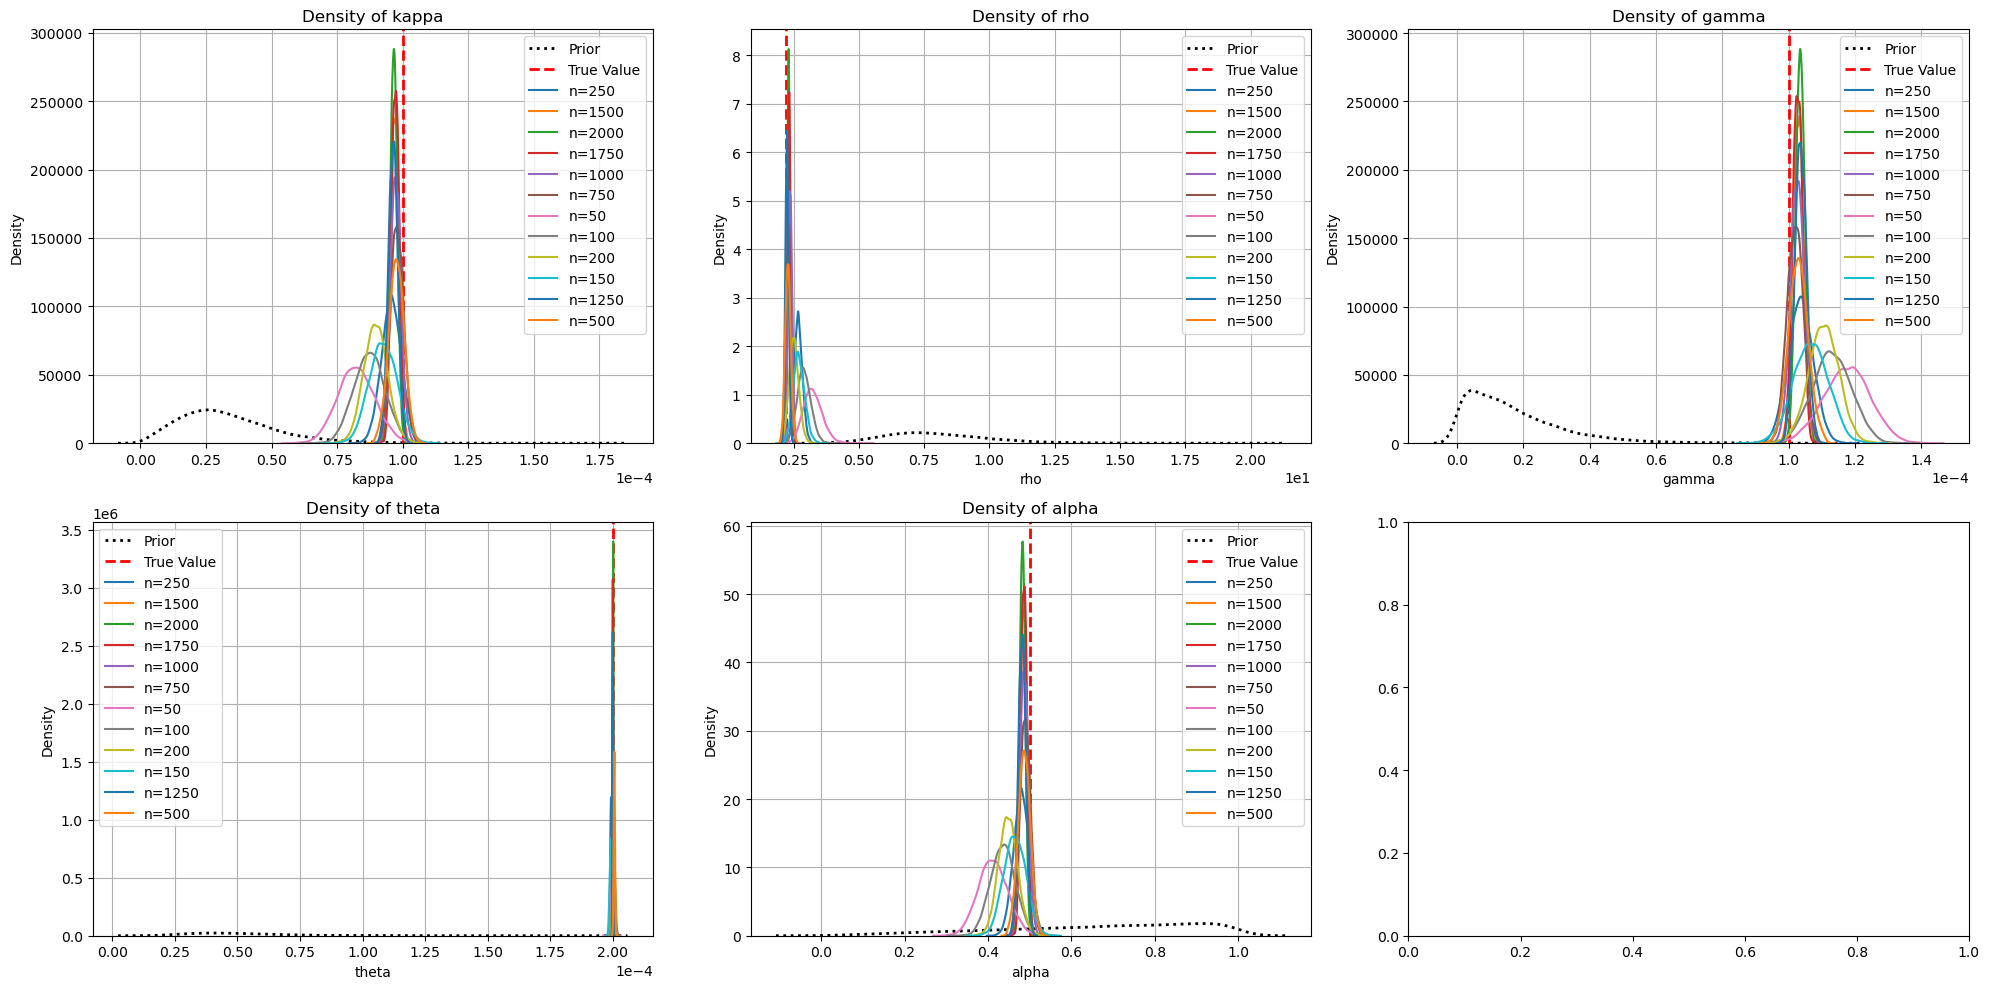

In [22]:
scaling = {"kappa": 1, "gamma": 1, "rho": 1, "theta": 1, "alpha": 1}
# Your existing code for loading posterior data
results_dir = '/nfs/home/dannis/AC-model/TIM/TIM_MCMC_Results/20250826'
files = [f for f in os.listdir(results_dir) if f.startswith('trace_') and f.endswith('103.nc')]

# Create subplots for all 5 parameters
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()  # Flatten the 2D array of axes for easy indexing

# Plot all parameters: kappa, rho, gamma, theta, alpha
for i, param in enumerate(['kappa', 'rho', 'gamma', 'theta', 'alpha']):
    # Plot prior - fix the dictionary access
    mu, std = prior_params[param].values() 
  
    sns.kdeplot(prior_samples[param]*scaling[param], fill=False, ax=axes[i], 
                color='black', linestyle=':', linewidth=2, label=f'Prior')
    
    # Plot true value
    axes[i].axvline(true_params[param]*scaling[param], color='red', linestyle='--', 
                    linewidth=2, label='True Value')
    
    # Plot posteriors for each n
    for file in files:
        idata = az.from_netcdf(os.path.join(results_dir, file))
        n = int(file.split('_')[1])
        vals = idata.posterior[param].values.reshape(-1)
        mean = np.mean(vals)
        std = np.std(vals)
        sns.kdeplot(vals*scaling[param], fill=False, ax=axes[i], 
                   label=f'n={n}')
    
    axes[i].set_title(f'Density of {param}')
    axes[i].set_xlabel(param)
    axes[i].set_ylabel('Density')
    axes[i].legend()
    axes[i].grid(True)
    
    # Format x-axis in scientific notation
    axes[i].ticklabel_format(style='scientific', axis='x', scilimits=(0,0))

plt.tight_layout()
plt.show()

In [23]:

def parameter_changes(n_trades, scaling, results_dir, prior_params, num_rounds=15):
    mean_dict = {parma: {n: [] for n in n_trades} for parma in prior_params.keys()}
    std_dict = {parma: {n: [] for n in n_trades} for parma in prior_params.keys()}
    
    for n in n_trades:
        for i in range(num_rounds):  
            files = [f for f in os.listdir(results_dir) if f.startswith(f'trace_{n}') and f.endswith(f'{i}.nc')]
            if files:  
                idata = az.from_netcdf(os.path.join(results_dir, files[0]))
                for param_name in prior_params.keys():
                    vals = idata.posterior[param_name].values.reshape(-1)
                    mean = float(np.mean(vals))
                    std = float(np.std(vals))
                    mean_dict[param_name][n].append(mean * scaling[param_name])
                    std_dict[param_name][n].append(std * scaling[param_name])
                                      
    return mean_dict, std_dict
available_n_trades = set()
for file in os.listdir(results_dir):
    if file.startswith('trace_') and file.endswith('.nc'):
        try:
            n_trade = int(file.split('_')[1])
            available_n_trades.add(n_trade)
        except (IndexError, ValueError):
            continue

# Convert to sorted list
available_n_trades = sorted(list(available_n_trades))

mean_dict, std_dict = parameter_changes(
    n_trades=available_n_trades,
    scaling=scaling,
    results_dir=results_dir,
    prior_params=prior_params,
    num_rounds=10)


In [24]:

# convert the mean 
df_mean = pd.DataFrame(mean_dict).stack().explode().reset_index().rename(columns={'level_0': 'n_trades', 'level_1': 'parameter', 0: 'mean'})
df_std = pd.DataFrame(std_dict).stack().explode().reset_index().rename(columns={'level_0': 'n_trades', 'level_1': 'parameter', 0: 'std'})


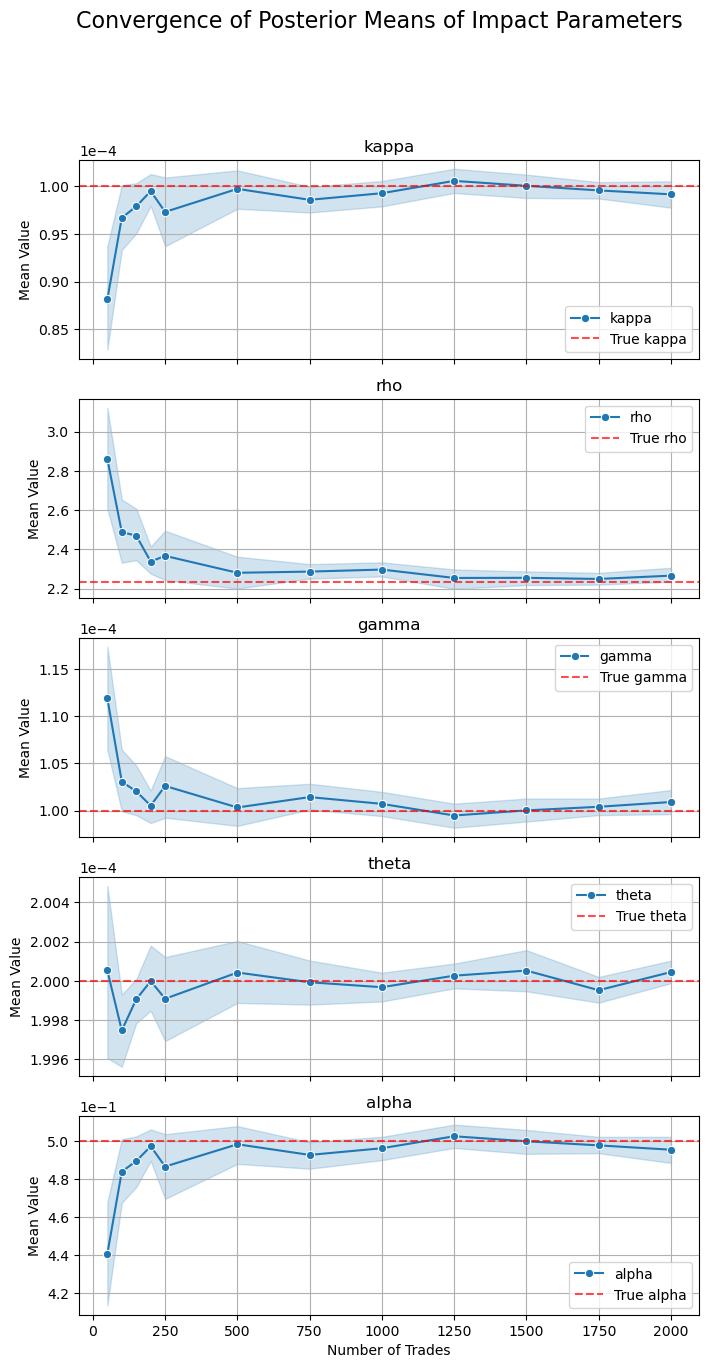

In [51]:
# Create the lineplot first
fig, axes = plt.subplots(len(true_params), 1, figsize=(8, 3 * len(true_params)), sharex=True)
for i, param in enumerate(true_params.keys()):
    ax = axes[i] if len(true_params) > 1 else axes
    sns.lineplot(data=df_mean[df_mean['parameter'] == param], x='n_trades', y='mean', marker='o', ax=ax, label=param)
    ax.axhline(true_params[param] * scaling[param], color='red', linestyle='--', alpha=0.7, label=f'True {param}')
    ax.set_title(param)
    ax.set_xlabel('Number of Trades')
    ax.set_ylabel('Mean Value')
    ax.legend()
    ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
    ax.grid(True)
fig.suptitle('Convergence of Posterior Means of Impact Parameters', fontsize=16)

plt.savefig('bayesian_posteriors.png')
plt.show()

In [32]:
df_mean.to_csv(os.path.join(results_dir, 'parameters_mean.csv'), index=False)
df_std.to_csv(os.path.join(results_dir, 'parameters_std.csv'), index=False)

# here

In [33]:
import pandas as pd
df_std = pd.read_csv(f'{results_dir}/parameters_std.csv')
df_mean = pd.read_csv(f'{results_dir}/parameters_mean.csv')

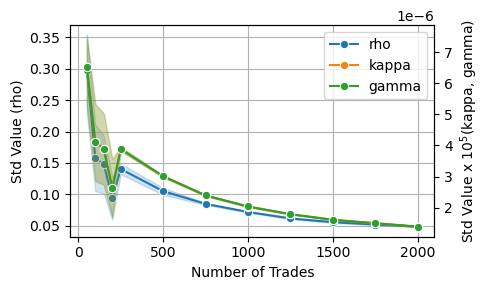

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

params = ['rho', 'kappa', 'gamma']
colors = ['C0', 'C1', 'C2']
fig, ax = plt.subplots(figsize=(5, 3))

# Plot rho on ax
sns.lineplot(
    data=df_std[df_mean['parameter'] == params[0]],
    x='n_trades', y='std',
    marker='o', ax=ax, color=colors[0]
)
ax.set_ylabel(f'Std Value ({params[0]})')

# Plot theta and alpha on ax2
ax2 = ax.twinx()
sns.lineplot(
    data=df_std[df_mean['parameter'] == params[1]],
    x='n_trades', y='std',
    marker='o', ax=ax2, color=colors[1]
)
sns.lineplot(
    data=df_std[df_mean['parameter'] == params[2]],
    x='n_trades', y='std',
    marker='o', ax=ax2, color=colors[2]
)
ax2.set_ylabel(f'Std Value x $10^5$({params[1]}, {params[2]})')

# Get the actual line handles correctly from the axes
line_rho = ax.lines[0]
line_theta = ax2.lines[0]
line_alpha = ax2.lines[1]

# Build the legend with correct labels
lines = [line_rho, line_theta, line_alpha]
labels = params
ax.legend(lines, labels, loc='best')

# Final polish
ax.set_xlabel('Number of Trades')
ax.grid(True)
plt.tight_layout()
plt.savefig('param_std_rkg.pdf', dpi=300)
plt.show()


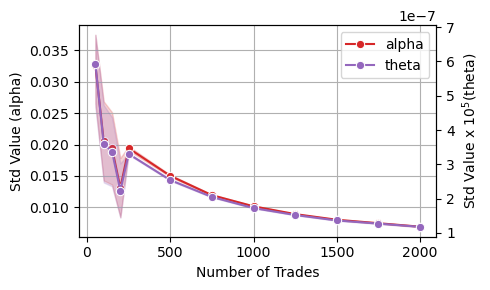

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

params = ['alpha', 'theta']
colors = ['C3', 'C4', ]
fig, ax = plt.subplots(figsize=(5, 3))

# Plot rho on ax
# Plot rho on ax
sns.lineplot(
    data=df_std[df_mean['parameter'] == params[0]],
    x='n_trades', y='std',
    marker='o', ax=ax, color=colors[0]
)
ax.set_ylabel(f'Std Value ({params[0]})')

# Plot theta and alpha on ax2
ax2 = ax.twinx()
sns.lineplot(
    data=df_std[df_mean['parameter'] == params[1]],
    x='n_trades', y='std',
    marker='o', ax=ax2, color=colors[1]
)
ax2.set_ylabel('Std Value x $10^5$'+f'({params[1]})')

# Get the actual line handles correctly from the axes
line_rho = ax.lines[0]
line_theta = ax2.lines[0]

# Build the legend with correct labels
lines = [line_rho, line_theta]
labels = params
ax.legend(lines, labels, loc='best')

# Final polish
ax.set_xlabel('Number of Trades')
ax.grid(True)
plt.tight_layout()
plt.savefig('param_std_alpha_theta.pdf', dpi=300)
plt.show()


In [36]:
df_std_params = df_std.groupby(['n_trades', 'parameter']).mean().reset_index().pivot(index='n_trades', columns='parameter', values='std')
df_std_params['theta'] = df_std_params['theta'] / 1e5

In [50]:
df_mean_params = df_mean.groupby(['n_trades', 'parameter']).mean()\
.reset_index().pivot(index='n_trades', columns='parameter', values='mean')


In [52]:
df_std_params

parameter,alpha,gamma,kappa,rho,theta
n_trades,,,,,
50,0.158222,0.337104,0.330504,1.808694,1.848630e-06
100,0.162914,0.343293,0.337846,1.923612,2.050702e-06
250,0.159766,0.335393,0.331482,1.888229,1.349766e-06
500,0.153949,0.312431,0.309858,1.709063,9.548122e-07
800,0.147910,0.301414,0.299714,1.572549,7.091207e-07
1100,0.145815,0.295458,0.293421,1.305183,5.953597e-07
1400,0.137740,0.277418,0.276110,1.514273,5.268546e-07


In [51]:
df_mean_params

parameter,alpha,gamma,kappa,rho,theta
n_trades,,,,,
50,0.468640,1.065435,0.940597,2.918347,2.006032
100,0.483649,1.024050,0.959926,2.990755,1.983976
250,0.477086,1.070317,0.968023,2.996194,2.038340
500,0.472549,1.050959,0.944539,2.897151,1.995498
800,0.496385,1.015689,1.003006,3.006680,2.018695
1100,0.468038,1.068384,0.939993,2.478819,2.008376
1400,0.475409,1.047934,0.950229,3.104485,1.998163


In [3]:
def inverse_beta_variance(std):
    """
    Computes alpha = beta given the variance of a Beta distribution 
    where alpha = beta.

    Parameters:
    var (float): variance of the Beta distribution (0 < var < 1/4)

    Returns:
    float: value of alpha = beta
    """
    var = std ** 2
    if var <= 0 or var >= 0.25:
        raise ValueError("Variance must be between 0 and 0.25 (exclusive).")
    return (1 / (8 * var)) - 0.5

df_std_params['alpha_dist_param'] = df_std_params['alpha'].apply(inverse_beta_variance)

In [4]:
df_std_params


parameter,alpha,gamma,kappa,rho,theta,alpha_dist_param
n_trades,,,,,,
50,0.158222,0.337104,0.330504,1.808694,1.848630e-06,4.493178
100,0.162914,0.343293,0.337846,1.923612,2.050702e-06,4.209689
250,0.159766,0.335393,0.331482,1.888229,1.349766e-06,4.397102
500,0.153949,0.312431,0.309858,1.709063,9.548122e-07,4.774210
800,0.147910,0.301414,0.299714,1.572549,7.091207e-07,5.213667
1100,0.145815,0.295458,0.293421,1.305183,5.953597e-07,5.379057
1400,0.137740,0.277418,0.276110,1.514273,5.268546e-07,6.088576


In [63]:

import numpy as np
def beta_mean(alpha, beta):
    """
    Computes the mean of the Beta distribution.

    Parameters:
    alpha (float): shape parameter alpha > 0
    beta (float): shape parameter beta > 0

    Returns:
    float: mean of the Beta distribution
    """
    return alpha / (alpha + beta)


def beta_variance(alpha, beta):
    """
    Computes the variance of the Beta distribution.

    Parameters:
    alpha (float): shape parameter alpha > 0
    beta (float): shape parameter beta > 0

    Returns:
    float: variance of the Beta distribution
    """
    denominator = (alpha + beta)**2 * (alpha + beta + 1)
    return (alpha * beta) / denominator
alpha = beta = 4.397102
print(f"Mean of Beta({alpha}, {beta}): {beta_mean(alpha, beta)}")
print(f"Variance of Beta({alpha}, {beta}): {beta_variance(alpha, beta)}")
print(f'Std. of Beta({alpha}, {beta}): {np.sqrt(beta_variance(alpha, beta))}')

alpha = beta = 6.088576
print(f"Mean of Beta({alpha}, {beta}): {beta_mean(alpha, beta)}")
print(f"Variance of Beta({alpha}, {beta}): {beta_variance(alpha, beta)}")
print(f'Std. of Beta({alpha}, {beta}): {np.sqrt(beta_variance(alpha, beta))}')
      

Mean of Beta(4.397102, 4.397102): 0.5
Variance of Beta(4.397102, 4.397102): 0.025525300473627055
Std. of Beta(4.397102, 4.397102): 0.15976639344251048
Mean of Beta(6.088576, 6.088576): 0.5
Variance of Beta(6.088576, 6.088576): 0.01897223315022852
Std. of Beta(6.088576, 6.088576): 0.13773972974501045


In [ ]:
df_std.query("parameter == 'alpha'").groupby('n_trades')['std'].mean()

n_trades
50      0.158222
100     0.162914
250     0.159766
500     0.153949
800     0.147910
1100    0.145815
1400    0.137740
Name: std, dtype: float64

## Optimization Results

In [2]:
results_path = '/nfs/home/dannis/AC-model/TIM_opt_results_20250628/1400_nscenarios_1000/opt_trace_1400_gap_100_seed_100.pkl'

with open(results_path, 'rb') as f:
    results = pickle.load(f)
    

In [12]:
results.keys()

dict_keys(['status', 'trades', 'obj_val', 'runtime', 'tail_prob', 'inventory', 'errors', 'kappa_samp', 'gamma_samp', 'rho_samp'])

In [14]:
results['obj_val']

738.3662649701603

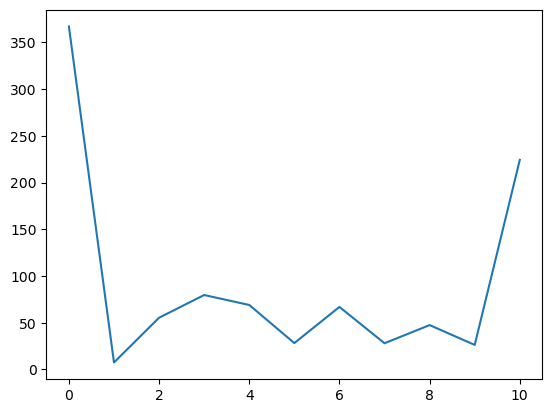

In [6]:
plt.plot(results['trades'])

In [8]:
results['inventory']

[[1000.0,
  632.8813378178959,
  625.405031572337,
  570.0261177797574,
  490.3410165568853,
  421.31641224702037,
  393.0872037355789,
  326.143193611067,
  298.09608776541586,
  250.60994821656587,
  224.3556205532532,
  -1.1368683772161603e-13]]

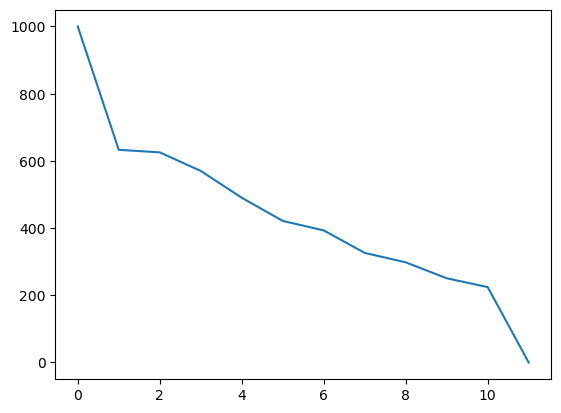

In [10]:
plt.plot(results['inventory'][0])

In [2]:
import os
import pickle
from collections import defaultdict

def collect_status_by_folder(base_path):
    result = {}
    gap_result = defaultdict(dict)

    for folder_name in os.listdir(base_path):
        folder_path = os.path.join(base_path, folder_name)
        if not os.path.isdir(folder_path):
            continue

        try:
            key = int(folder_name.split('_')[0])  # Extract leading integer
        except ValueError:
            continue

        status_dict = defaultdict(list)

        for file_name in os.listdir(folder_path):
            
            if not file_name.endswith('.pkl'):
                continue
            n_sample = file_name.split('_')[2]
            seed = file_name.split('_')[-1].split('.')[0]
            
            file_path = os.path.join(folder_path, file_name)
            try:
                with open(file_path, 'rb') as f:
                    data = pickle.load(f)
                status = data.get('status', 'UNKNOWN')
                status_dict[status].append(file_name)
                gap = data.get('mip_gap', None)  # Assuming 'gap' is a key in the data
                gap_result[n_sample][seed] = gap
                
            except Exception as e:
                print(f"Failed to load {file_path}: {e}")

        result[key] = dict(status_dict)

    return result, gap_result

# Example usage:
base_dir = '/nfs/home/dannis/AC-model/TIM_opt_results_20250628'  # replace with the actual full path if needed
status_summary, gap_summary = collect_status_by_folder(base_dir)

# Print or inspect the result
for key, value in status_summary.items():
    print('seed', key)
    for status, files in value.items():
        print('status:', status,
              'count:', len(files))

seed 250
status: 9 count: 11
status: 2 count: 4
seed 800
status: 9 count: 22
status: 2 count: 7
seed 500
status: 9 count: 20
status: 2 count: 9
seed 1100
status: 9 count: 22
status: 2 count: 8
seed 1400
status: 9 count: 21
status: 2 count: 8
status: 13 count: 1
seed 100
status: 9 count: 11
status: 2 count: 4


In [3]:
import re

def extract_gap_and_filename(file_path, gap_dict):
    with open(file_path, 'r') as f:
        lines = f.readlines()

    results = []
    current_trace_file = None
    last_gap = None
    trace_number = None
    for i, line in enumerate(lines):
        # Check for trace file declaration
        
        if 'Processing trace file:' in line and ('TIM_MCMC_Results') not in line:
            print(f"Line {i+1}: {line.strip()}")
            
            match = re.search(r'trace_(\d+)_', line)
            if match:
                match_trace = re.search(r'trace_(\d+)_', line)
                trace_number = match_trace.group(1) if match_trace else None

                # Extract number before '.nc' (after 'seed_')
                match_seed = re.search(r'seed_(\d+)\.nc', line)
                seed_string = match_seed.group(1) if match_seed else None
                print(f"Trace Number: {trace_number}, Seed: {seed_string}")

        # Check for gap value
        if 'gap ' in line and '%' in line:
            print(f"Line {i+1}: {line.strip()}")
            match = re.search(r'gap ([\d.]+)%', line)
            
            gap_value = float(match.group(1)) if match else None
            gap_value /= 100
            if trace_number is not None:
                gap_dict[trace_number][seed_string] = gap_value
            trace_number = None
        # Check for Optimization Status
        if 'Optimization Status' in line:
            results.append({
                'trace_file': current_trace_file,
                'gap_percent': last_gap
            })

    return results

# file_path = '/nfs/home/dannis/AC-model/TIM_opt_results_20250628/run_log_100_250.txt'

log_file_paths = [
 'run_log_1100_1400_0701.txt',
 'run_log_500_500_0701.txt',
 'run_log_100_250.txt',
 'run_log_800.txt',
 'run_log_1100_1400.txt',
 'run_log_500.txt',
 'run_log_500_800.txt',
 'run_log_1400_0713_0.txt',
 'run_log_1100_1400_0713_1.txt'
 ]
# Example usage
for file_name in log_file_paths:
    # change this to your file
    results = extract_gap_and_filename(os.path.join(base_dir, file_name), gap_summary)

for item in results:
    print(f"Trace File: {item['trace_file']}, Gap: {item['gap_percent']}%")


Line 2: Processing trace file: trace_1400_gap_100_seed_115.nc
Trace Number: 1400, Seed: 115
Line 2: Processing trace file: trace_500_gap_100_seed_121.nc
Trace Number: 500, Seed: 121
Line 2: Processing trace file: trace_100_gap_100_seed_100.nc
Trace Number: 100, Seed: 100
Line 108: Best objective 6.719379106419e+02, best bound 6.710599789625e+02, gap 0.1307%
Line 111: Processing trace file: trace_100_gap_100_seed_101.nc
Trace Number: 100, Seed: 101
Line 733: Best objective 7.101453027452e+02, best bound 7.051191403189e+02, gap 0.7078%
Line 736: Processing trace file: trace_100_gap_100_seed_102.nc
Trace Number: 100, Seed: 102
Line 1351: Best objective 7.319042860059e+02, best bound 7.191475570644e+02, gap 1.7430%
Line 1354: Processing trace file: trace_100_gap_100_seed_103.nc
Trace Number: 100, Seed: 103
Line 1978: Best objective 9.046134847960e+02, best bound 8.037654350704e+02, gap 11.1482%
Line 1981: Processing trace file: trace_100_gap_100_seed_104.nc
Trace Number: 100, Seed: 104
Lin

In [4]:
gap_summary

defaultdict(dict,
            {'250': {'104': 0.077954,
              '100': 0.007991,
              '101': 0.000334,
              '107': 0.031200000000000002,
              '106': 0.001935,
              '105': 0.0,
              '111': 0.087098,
              '108': 0.014699,
              '112': 0.065739,
              '110': 0.061219,
              '103': 0.0,
              '109': 0.007633999999999999,
              '114': 0.003356,
              '113': 0.026067999999999997,
              '102': 0.005523},
             '800': {'112': 0.016596,
              '104': 0.00226,
              '118': 0.039438966549168286,
              '108': 0.064149,
              '111': 0.025467,
              '119': 0.030891407687968532,
              '121': 0.001974283731445646,
              '124': 0.01697151263281456,
              '122': 0.0,
              '100': 0.03447,
              '128': 0.004336965533481853,
              '125': 0.07015589998331252,
              '109': 0.001924,
          

In [5]:
gap_thresh = 0.01
gap_summary_2 = defaultdict(list)
for n,v in sorted(gap_summary.items()):
    for seed, gap in v.items():
        if gap is not None and gap < gap_thresh:
            gap_summary_2[n].append(seed)

for n, seeds in gap_summary_2.items():
    print(f"n_trades: {n}, n seeds with gap < {gap_thresh:.2%}: {len(seeds)}")

n_trades: 100, n seeds with gap < 1.00%: 7
n_trades: 1100, n seeds with gap < 1.00%: 12
n_trades: 1400, n seeds with gap < 1.00%: 13
n_trades: 250, n seeds with gap < 1.00%: 8
n_trades: 500, n seeds with gap < 1.00%: 16
n_trades: 800, n seeds with gap < 1.00%: 12


In [6]:
gap_summary_2

defaultdict(list,
            {'100': ['109', '114', '112', '101', '104', '105', '100'],
             '1100': ['127',
              '101',
              '121',
              '104',
              '109',
              '114',
              '105',
              '123',
              '122',
              '102',
              '126',
              '120'],
             '1400': ['128',
              '100',
              '119',
              '117',
              '127',
              '104',
              '109',
              '124',
              '105',
              '126',
              '106',
              '120',
              '129'],
             '250': ['100', '101', '106', '105', '103', '109', '114', '102'],
             '500': ['109',
              '122',
              '100',
              '119',
              '116',
              '123',
              '105',
              '128',
              '107',
              '121',
              '124',
              '120',
              '104',
          

In [7]:
# Or save as pickle (preserves Python data types)
with open('gap_summary_full.pkl', 'wb') as f:
    pickle.dump(gap_summary, f)

with open('gap_summary_2.pkl', 'wb') as f:
    pickle.dump({'thresh': gap_thresh,
                 'ntrade_seeds': gap_summary_2}, f)